__Problem Statement:__ Today, 1.85 million different apps are available for users to download. Android users have even more from which to choose, with 2.56 million available through Google Play Store. These apps have come to play a huge role in the way we live our lives today. Our objective is to find the most pooular category, find the app with the largest number of installs, the app with largest size etc.

__Data Collection:__ The data consists of 20 columns and 10841 rows

__Steps:__
1. Data Cleaning
2. EDA
3. Feature Engineering

In [9]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

In [10]:
df = pd.read_csv('googleplaystore.csv')
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [11]:
df.shape

(10841, 13)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), str(12)
memory usage: 1.1 MB


In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Rating,9367.0,4.193338,0.537431,1.0,4.0,4.3,4.5,19.0


In [14]:
df.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

__Observations:__
- The dataset has missing values, primarily in rating - 1474.
- Median rating is 4.3
- Everything is an object(str) except Rating


In [15]:
# Data Cleaning 

df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [16]:
# Converting reviews to int from str 

df['Reviews'].astype(int)


ValueError: invalid literal for int() with base 10: '3.0M'

In [17]:
# This means there is a non numeric data called '3.0M' in ratings. Let's find out
df[~df['Reviews'].str.isnumeric()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [18]:
# Let's drop it
# Creating a new dataframe 

df_cleaned = df.copy()

In [19]:
df_cleaned = df_cleaned.drop(df_cleaned.index[10472])

In [20]:
#Convert Review Data Type to Int
df_cleaned['Reviews'] = df_cleaned['Reviews'].astype(int)

In [21]:
df_cleaned.info()

<class 'pandas.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  str    
 1   Category        10840 non-null  str    
 2   Rating          9366 non-null   float64
 3   Reviews         10840 non-null  int64  
 4   Size            10840 non-null  str    
 5   Installs        10840 non-null  str    
 6   Type            10839 non-null  str    
 7   Price           10840 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10840 non-null  str    
 10  Last Updated    10840 non-null  str    
 11  Current Ver     10832 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), int64(1), str(11)
memory usage: 1.2 MB


In [22]:
# Size - This one has value in thousands(k) and millions (M).
# We need to make the values uniform 

df_cleaned['Size'].unique()

<StringArray>
[  '19M',   '14M',  '8.7M',   '25M',  '2.8M',  '5.6M',   '29M',   '33M',
  '3.1M',   '28M',
 ...
  '467k',  '157k',   '44k',  '676k',   '67k',  '552k',  '885k', '1020k',
  '582k',  '619k']
Length: 461, dtype: str

In [23]:
#Let's first check for null values 
df_cleaned['Size'].isnull().sum()

np.int64(0)

In [24]:
#Let's also see if there are any other patterns other than M and K.

#Using regex
patterns = df_cleaned['Size'].str.replace(r'[0-9.]', '', regex=True).unique()
print(patterns)

<StringArray>
['M', 'Varies with device', 'k']
Length: 3, dtype: str


In [25]:
# Let's convert everything to k 

df_cleaned['Size'] = df_cleaned['Size'].str.replace('M', '000')
df_cleaned['Size'] = df_cleaned['Size'].str.replace('k', '')
df_cleaned['Size'] = df_cleaned['Size'].replace('Varies with device', np.nan)
df_cleaned['Size'] = df_cleaned['Size'].astype(float)


In [26]:
df_cleaned.info()

<class 'pandas.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  str    
 1   Category        10840 non-null  str    
 2   Rating          9366 non-null   float64
 3   Reviews         10840 non-null  int64  
 4   Size            9145 non-null   float64
 5   Installs        10840 non-null  str    
 6   Type            10839 non-null  str    
 7   Price           10840 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10840 non-null  str    
 10  Last Updated    10840 non-null  str    
 11  Current Ver     10832 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(2), int64(1), str(10)
memory usage: 1.2 MB


In [27]:
df_cleaned.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000.0,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [28]:
# Installs

df_cleaned['Installs'].unique()

<StringArray>
[       '10,000+',       '500,000+',     '5,000,000+',    '50,000,000+',
       '100,000+',        '50,000+',     '1,000,000+',    '10,000,000+',
         '5,000+',   '100,000,000+', '1,000,000,000+',         '1,000+',
   '500,000,000+',            '50+',           '100+',           '500+',
            '10+',             '1+',             '5+',             '0+',
              '0']
Length: 21, dtype: str

In [29]:
# Price 

df_cleaned['Price'].unique()

<StringArray>
[      '0',   '$4.99',   '$3.99',   '$6.99',   '$1.49',   '$2.99',   '$7.99',
   '$5.99',   '$3.49',   '$1.99',   '$9.99',   '$7.49',   '$0.99',   '$9.00',
   '$5.49',  '$10.00',  '$24.99',  '$11.99',  '$79.99',  '$16.99',  '$14.99',
   '$1.00',  '$29.99',  '$12.99',   '$2.49',  '$10.99',   '$1.50',  '$19.99',
  '$15.99',  '$33.99',  '$74.99',  '$39.99',   '$3.95',   '$4.49',   '$1.70',
   '$8.99',   '$2.00',   '$3.88',  '$25.99', '$399.99',  '$17.99', '$400.00',
   '$3.02',   '$1.76',   '$4.84',   '$4.77',   '$1.61',   '$2.50',   '$1.59',
   '$6.49',   '$1.29',   '$5.00',  '$13.99', '$299.99', '$379.99',  '$37.99',
  '$18.99', '$389.99',  '$19.90',   '$8.49',   '$1.75',  '$14.00',   '$4.85',
  '$46.99', '$109.99', '$154.99',   '$3.08',   '$2.59',   '$4.80',   '$1.96',
  '$19.40',   '$3.90',   '$4.59',  '$15.46',   '$3.04',   '$4.29',   '$2.60',
   '$3.28',   '$4.60',  '$28.99',   '$2.95',   '$2.90',   '$1.97', '$200.00',
  '$89.99',   '$2.56',  '$30.99',   '$3.61', '$394

In [30]:
#Cleaning special chars from Installs and Price 

chars_to_remove = ['+', ',', '$']
columns_to_clean = ['Installs', 'Price']

for item in chars_to_remove:
    for cols in columns_to_clean:
        df_cleaned[cols] = df_cleaned[cols].str.replace(item,'')

In [31]:
df_cleaned['Installs'].unique()

<StringArray>
[     '10000',     '500000',    '5000000',   '50000000',     '100000',
      '50000',    '1000000',   '10000000',       '5000',  '100000000',
 '1000000000',       '1000',  '500000000',         '50',        '100',
        '500',         '10',          '1',          '5',          '0']
Length: 20, dtype: str

In [32]:
df_cleaned['Price'].unique()

<StringArray>
[     '0',   '4.99',   '3.99',   '6.99',   '1.49',   '2.99',   '7.99',
   '5.99',   '3.49',   '1.99',   '9.99',   '7.49',   '0.99',   '9.00',
   '5.49',  '10.00',  '24.99',  '11.99',  '79.99',  '16.99',  '14.99',
   '1.00',  '29.99',  '12.99',   '2.49',  '10.99',   '1.50',  '19.99',
  '15.99',  '33.99',  '74.99',  '39.99',   '3.95',   '4.49',   '1.70',
   '8.99',   '2.00',   '3.88',  '25.99', '399.99',  '17.99', '400.00',
   '3.02',   '1.76',   '4.84',   '4.77',   '1.61',   '2.50',   '1.59',
   '6.49',   '1.29',   '5.00',  '13.99', '299.99', '379.99',  '37.99',
  '18.99', '389.99',  '19.90',   '8.49',   '1.75',  '14.00',   '4.85',
  '46.99', '109.99', '154.99',   '3.08',   '2.59',   '4.80',   '1.96',
  '19.40',   '3.90',   '4.59',  '15.46',   '3.04',   '4.29',   '2.60',
   '3.28',   '4.60',  '28.99',   '2.95',   '2.90',   '1.97', '200.00',
  '89.99',   '2.56',  '30.99',   '3.61', '394.99',   '1.26',   '1.20',
   '1.04']
Length: 92, dtype: str

In [33]:
# Converting both to int 

df_cleaned['Installs'] = df_cleaned['Installs'].astype('int')
df_cleaned['Price'] = df_cleaned['Price'].astype('float')

In [34]:
df_cleaned.info()

<class 'pandas.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  str    
 1   Category        10840 non-null  str    
 2   Rating          9366 non-null   float64
 3   Reviews         10840 non-null  int64  
 4   Size            9145 non-null   float64
 5   Installs        10840 non-null  int64  
 6   Type            10839 non-null  str    
 7   Price           10840 non-null  float64
 8   Content Rating  10840 non-null  str    
 9   Genres          10840 non-null  str    
 10  Last Updated    10840 non-null  str    
 11  Current Ver     10832 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(3), int64(2), str(8)
memory usage: 1.2 MB


In [35]:
# Handling Last Updated
df_cleaned['Last Updated'].unique()

<StringArray>
[   'January 7, 2018',   'January 15, 2018',     'August 1, 2018',
       'June 8, 2018',      'June 20, 2018',     'March 26, 2017',
     'April 26, 2018',      'June 14, 2018', 'September 20, 2017',
       'July 3, 2018',
 ...
  'November 23, 2015',      'June 17, 2012',  'February 27, 2015',
  'December 18, 2013',   'February 6, 2012',  'November 25, 2014',
       'May 19, 2016',   'January 20, 2014',  'February 16, 2014',
     'March 23, 2014']
Length: 1377, dtype: str

In [37]:
# Converting to datetime
df_cleaned['Last Updated']= pd.to_datetime(df_cleaned['Last Updated'])


In [40]:
#Extracting day,month and year from Last Updated

df_cleaned['Last Updated Day'] = df_cleaned['Last Updated'].dt.day
df_cleaned['Last Updated Month'] = df_cleaned['Last Updated'].dt.month
df_cleaned['Last Updated Year'] = df_cleaned['Last Updated'].dt.year


In [41]:
df_cleaned.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Last Updated Day,Last Updated Month,Last Updated Year
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,7,1,2018
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,15,1,2018
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,1,8,2018
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000.0,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,8,6,2018
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,20,6,2018


In [ ]:
df_cleaned['Last Updated Year'].unique() # We need to retain year

array([2018, 2017, 2014, 2016, 2015, 2013, 2012, 2011, 2010], dtype=int32)

---

In [ ]:
# Downloading a CSV for the cleaned dataset - good practice

df_cleaned.to_csv('playstore_cleaned_dataset.csv')

In [47]:
df_cleaned.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Last Updated Day,Last Updated Month,Last Updated Year
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,7,1,2018
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,15,1,2018
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,1,8,2018
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000.0,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,8,6,2018
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,20,6,2018


In [55]:
#Let's see duplicate records.

df_cleaned[df_cleaned.duplicated('App')]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Last Updated Day,Last Updated Month,Last Updated Year
229,Quick PDF Scanner + OCR FREE,BUSINESS,4.2,80805,NaN,5000000,Free,0.0,Everyone,Business,2018-02-26,Varies with device,4.0.3 and up,26,2,2018
236,Box,BUSINESS,4.2,159872,NaN,10000000,Free,0.0,Everyone,Business,2018-07-31,Varies with device,Varies with device,31,7,2018
239,Google My Business,BUSINESS,4.4,70991,NaN,5000000,Free,0.0,Everyone,Business,2018-07-24,2.19.0.204537701,4.4 and up,24,7,2018
256,ZOOM Cloud Meetings,BUSINESS,4.4,31614,37000.0,10000000,Free,0.0,Everyone,Business,2018-07-20,4.1.28165.0716,4.0 and up,20,7,2018
261,join.me - Simple Meetings,BUSINESS,4.0,6989,NaN,1000000,Free,0.0,Everyone,Business,2018-07-16,4.3.0.508,4.4 and up,16,7,2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10715,FarmersOnly Dating,DATING,3.0,1145,1.4,100000,Free,0.0,Mature 17+,Dating,2016-02-25,2.2,4.0 and up,25,2,2016
10720,Firefox Focus: The privacy browser,COMMUNICATION,4.4,36981,4.0,1000000,Free,0.0,Everyone,Communication,2018-07-06,5.2,5.0 and up,6,7,2018
10730,FP Notebook,MEDICAL,4.5,410,60000.0,50000,Free,0.0,Everyone,Medical,2018-03-24,2.1.0.372,4.4 and up,24,3,2018
10753,Slickdeals: Coupons & Shopping,SHOPPING,4.5,33599,12000.0,1000000,Free,0.0,Everyone,Shopping,2018-07-30,3.9,4.4 and up,30,7,2018


In [70]:
print(f'Total number of records: {df_cleaned.shape}')
print(f'Duplicate records: {df_cleaned[df_cleaned.duplicated('App')].shape}')

print(f'Duplicate percentage : {df_cleaned.shape[0]/df_cleaned[df_cleaned.duplicated('App')].shape[0]}%')

Total number of records: (10840, 16)
Duplicate records: (1181, 16)
Duplicate percentage : 9.17866215071973%


In [71]:
#Dropping Duplicates 

df_cleaned = df_cleaned.drop_duplicates(subset='App', keep='first') #subset='App' → checks duplicates based on the App column and keep='first' → keeps the first occurrence, removes the rest

In [72]:
df_cleaned.shape

(9659, 16)

In [88]:
# Numerical and Categorical features

numerical_features = df_cleaned.select_dtypes(include=['number']).columns
print(f'\nBelow are the {len(numerical_features)} numerical features:')
for i in numerical_features:
    print(f'- {i}')

categorical_features = df_cleaned.select_dtypes(include=['object', 'category']).columns
print(f'\nBelow are the {len(categorical_features)} categorical features:')
for j in categorical_features:
    print(f'- {j}')


Below are the 8 numerical features:
- Rating
- Reviews
- Size
- Installs
- Price
- Last Updated Day
- Last Updated Month
- Last Updated Year

Below are the 7 categorical features:
- App
- Category
- Type
- Content Rating
- Genres
- Current Ver
- Android Ver


In [ ]:
# A more beatutiful output - just for learning

numerical_features = df_cleaned.select_dtypes(include=['number']).columns
categorical_features = df_cleaned.select_dtypes(include=['object', 'category']).columns

print(f"\n📊 Numerical Features ({len(numerical_features)}):")
print("-" * 40)
for i, col in enumerate(numerical_features, 1):
    print(f"{i:>2}. {col}")

print(f"\n📝 Categorical Features ({len(categorical_features)}):")
print("-" * 40)
for j, col in enumerate(categorical_features, 1):
    print(f"{j:>2}. {col}")


📊 Numerical Features (8):
----------------------------------------
 1. Rating
 2. Reviews
 3. Size
 4. Installs
 5. Price
 6. Last Updated Day
 7. Last Updated Month
 8. Last Updated Year

📝 Categorical Features (7):
----------------------------------------
 1. App
 2. Category
 3. Type
 4. Content Rating
 5. Genres
 6. Current Ver
 7. Android Ver


In [ ]:
#Note - DateTime feature is not added because it is niether numerical nor categorical. 

In [ ]:
# Categorical Distribution

#value_counts() → absolute frequency
#value_counts(normalize=True) → relative frequency (proportion)

for col in categorical_features:
    print(f"\n🔹 {col}")
    print("Counts:")
    print(df[col].value_counts())
    
    print("\nPercentages:")
    print(df[col].value_counts(normalize=True).mul(100).round(2))
    
    print("-" * 40)


🔹 App
Counts:
App
ROBLOX                                               9
CBS Sports App - Scores, News, Stats & Watch Live    8
Duolingo: Learn Languages Free                       7
Candy Crush Saga                                     7
8 Ball Pool                                          7
                                                    ..
Sya9a Maroc - FR                                     1
Fr. Mike Schmitz Audio Teachings                     1
Parkinson Exercices FR                               1
The SCP Foundation DB fr nn5n                        1
iHoroscope - 2018 Daily Horoscope & Astrology        1
Name: count, Length: 9660, dtype: int64

Percentages:
App
ROBLOX                                               0.08
CBS Sports App - Scores, News, Stats & Watch Live    0.07
Duolingo: Learn Languages Free                       0.06
Candy Crush Saga                                     0.06
8 Ball Pool                                          0.06
                            

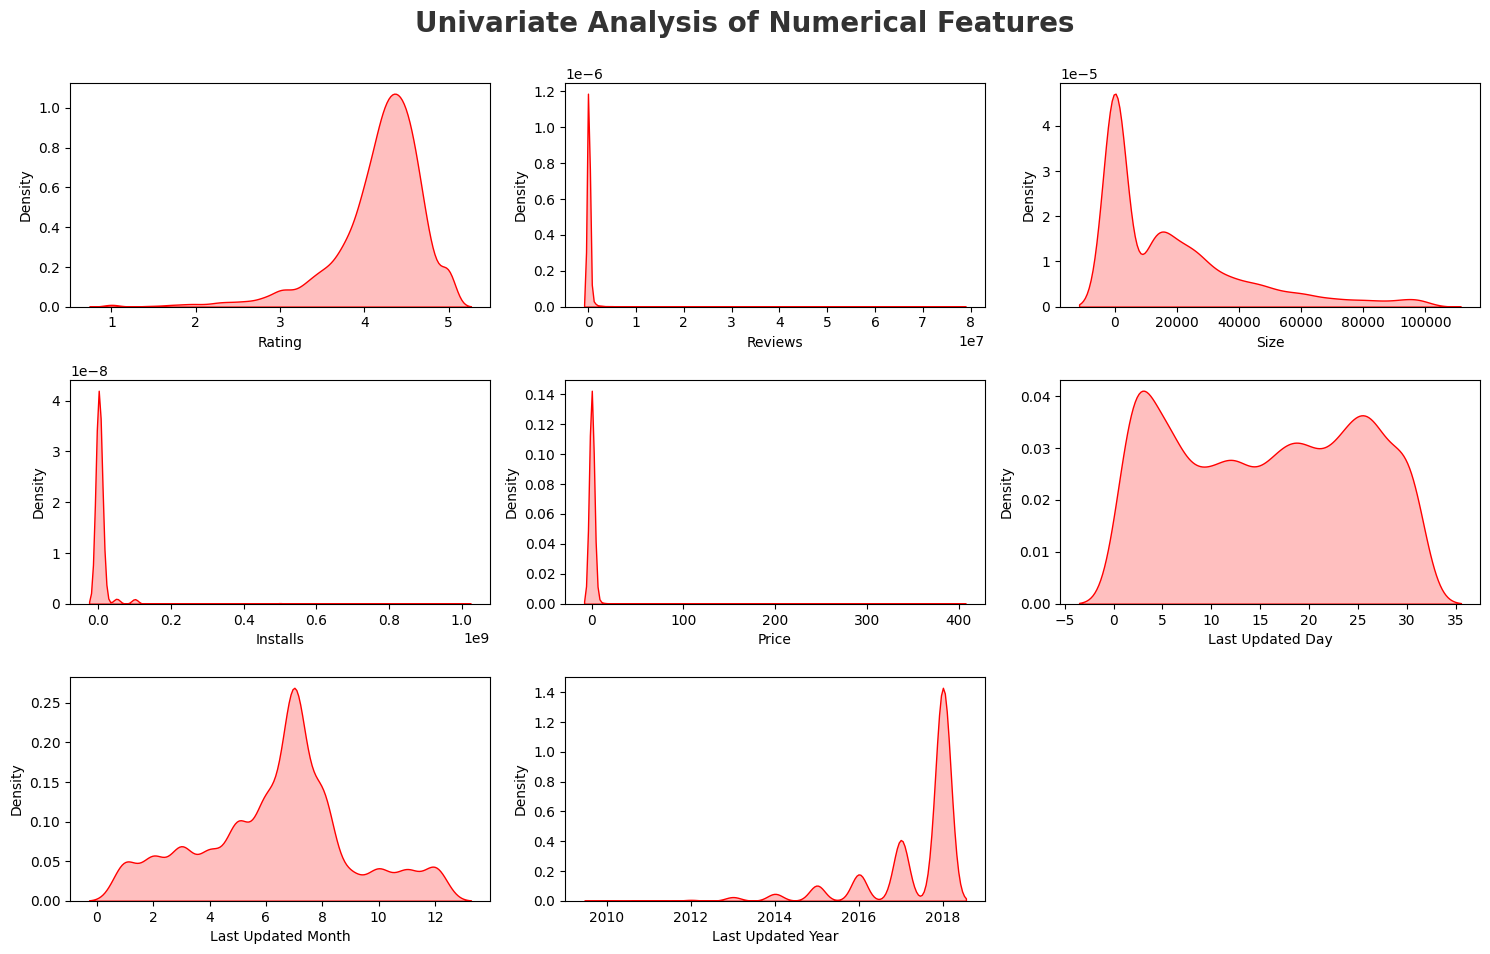

In [95]:
# Numerical feature univariate analysis 

plt.figure(figsize=(15,15))
plt.suptitle('Univariate Analysis of Numerical Features', fontsize = 20, fontweight = 'bold', alpha = 0.8, y=1)

for i in range (0, len(numerical_features)):
    plt.subplot(5,3,i+1)
    sns.kdeplot(x=df_cleaned[numerical_features[i]], fill = True, color = 'r')
    plt.xlabel(numerical_features[i])
    plt.tight_layout()

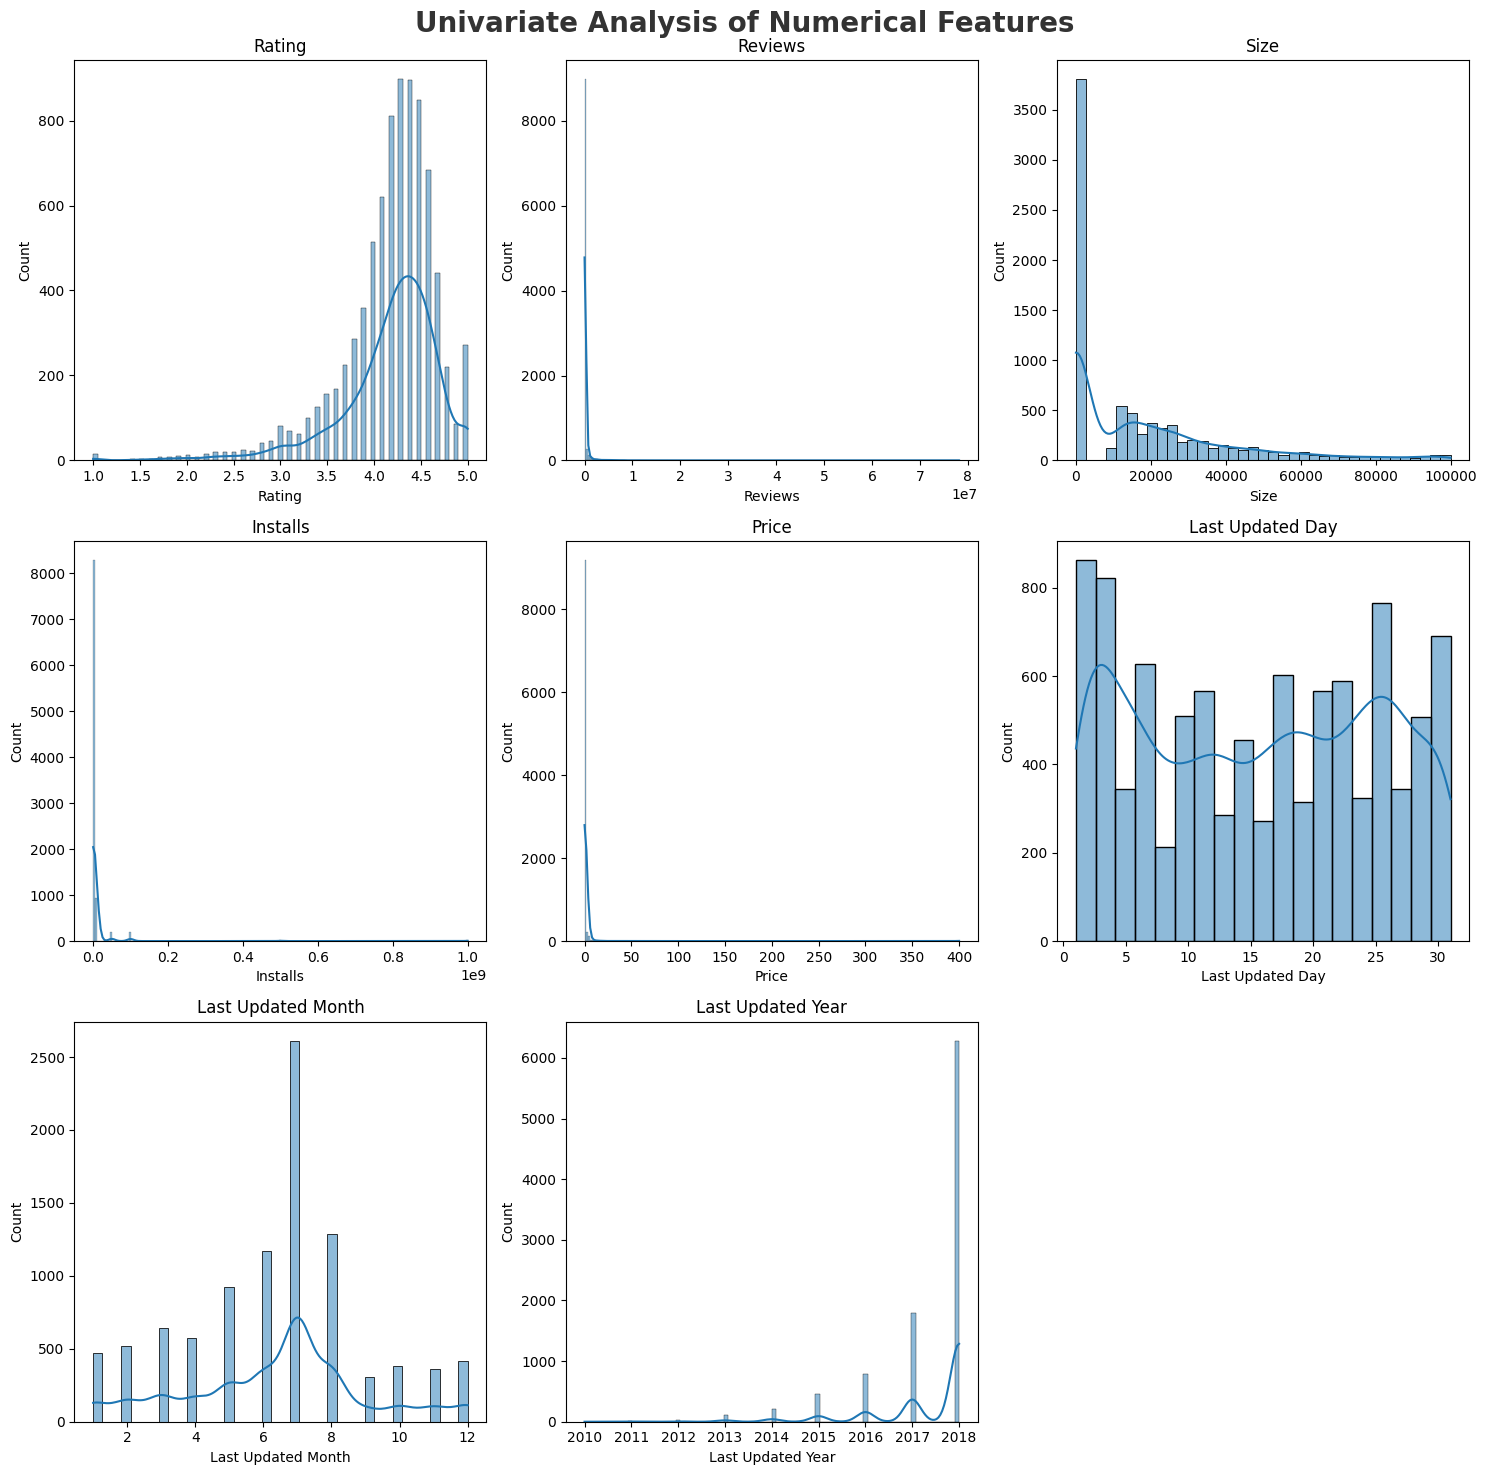

In [ ]:
#Another way to do it

import math
import seaborn as sns
import matplotlib.pyplot as plt

n_cols = 3
n_rows = math.ceil(len(numerical_features) / n_cols)

plt.figure(figsize=(15, 5 * n_rows))
plt.suptitle('Univariate Analysis of Numerical Features',
             fontsize=20, fontweight='bold', alpha=0.8)

for i, col in enumerate(numerical_features):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(df_cleaned[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

In [100]:
# Skewness
df_cleaned[numerical_features].skew()

Rating                -1.743965
Reviews               26.573459
Size                   1.468843
Installs              15.037532
Price                 22.530325
Last Updated Day      -0.008355
Last Updated Month    -0.049598
Last Updated Year     -2.157766
dtype: float64

In [105]:
# A better way tp go about this is thorugh cardinality. Cardinality refers to the number of unique values in a column (feature).

for col in categorical_features:
    print(col, df_cleaned[col].nunique())

App 9659
Category 33
Type 2
Content Rating 6
Genres 118
Current Ver 2817
Android Ver 33


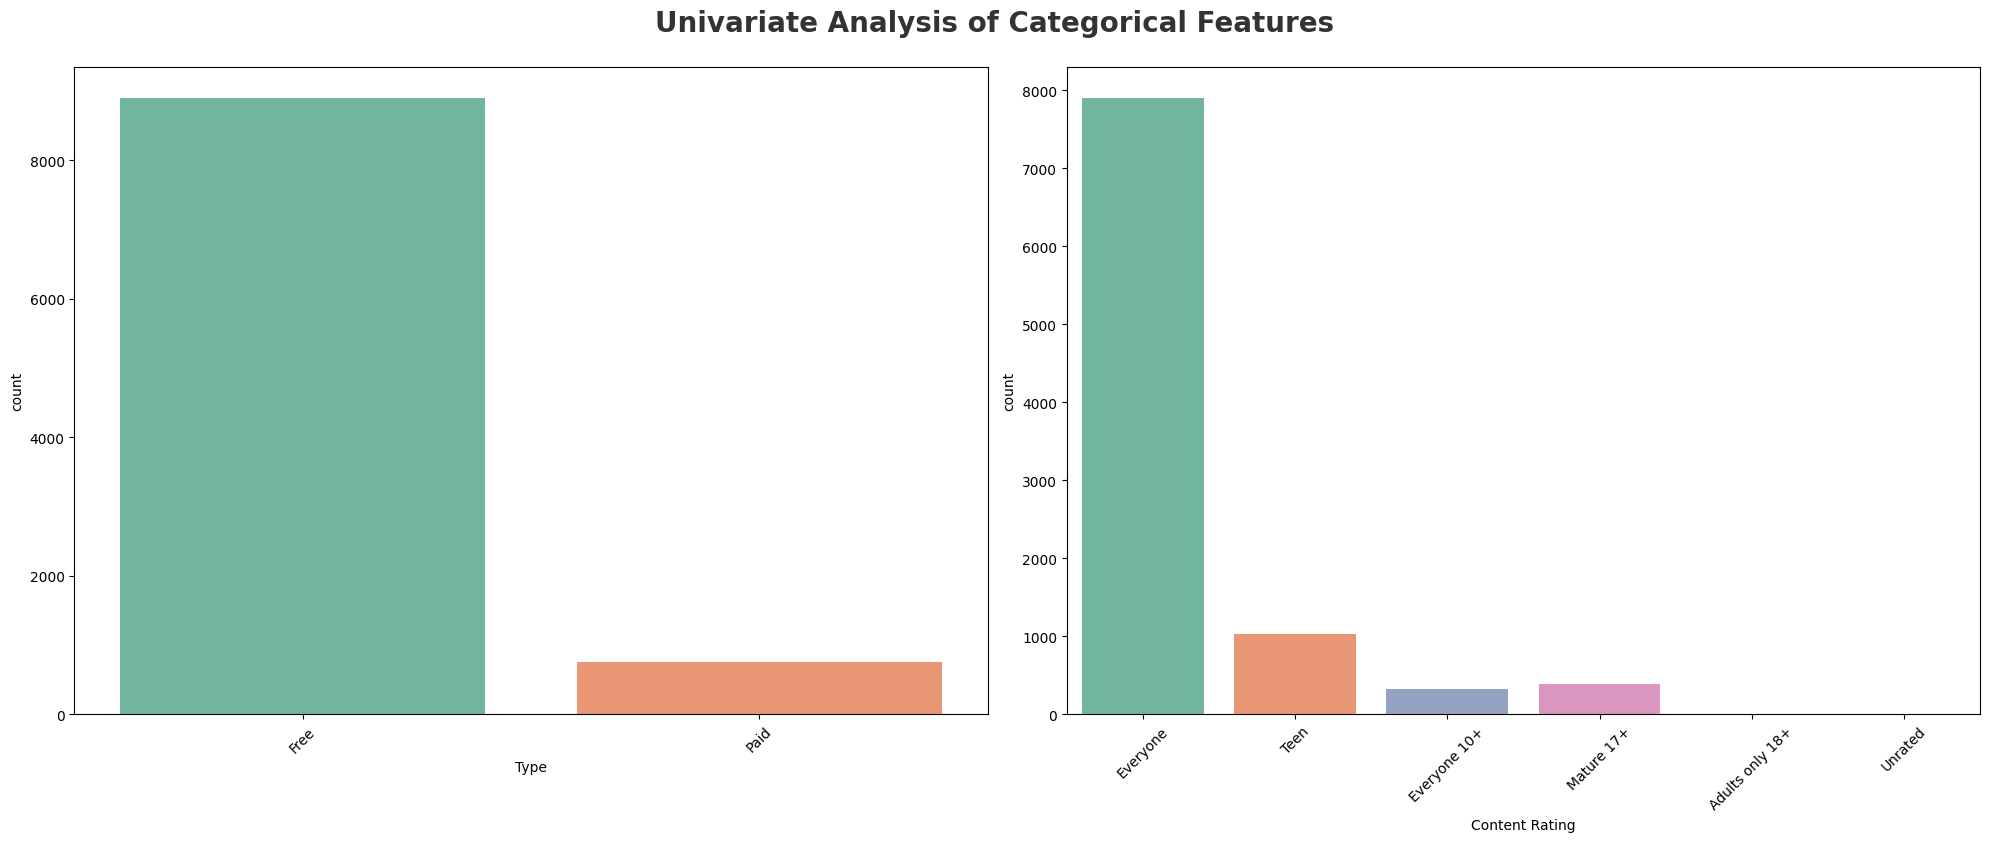

In [ ]:
# Categorical feature univariate analysis - these are for low cardinality features - type and content rating

plt.figure(figsize=(20,15))
plt.suptitle('Univariate Analysis of Categorical Features', fontsize = 20, fontweight = 'bold', alpha = 0.8, y=1.)
category = ['Type', 'Content Rating']

for i in range(0, len(category)):
    plt.subplot(2,2,i+1)
    sns.countplot(x = df_cleaned[category[i]], palette='Set2')
    plt.xlabel(category[i])
    plt.xticks(rotation =45)
    plt.tight_layout()

In [119]:
#Another way to go about it 

# Split + exclude identifier-like columns (not useful for categorical distribution plots)
exclude_cols = ['App', 'Current Ver']

low_cardinality = [
    col for col in categorical_features 
    if df_cleaned[col].nunique() <= 10 and col not in exclude_cols
]

high_cardinality = [
    col for col in categorical_features 
    if df_cleaned[col].nunique() > 10 and col not in exclude_cols
]

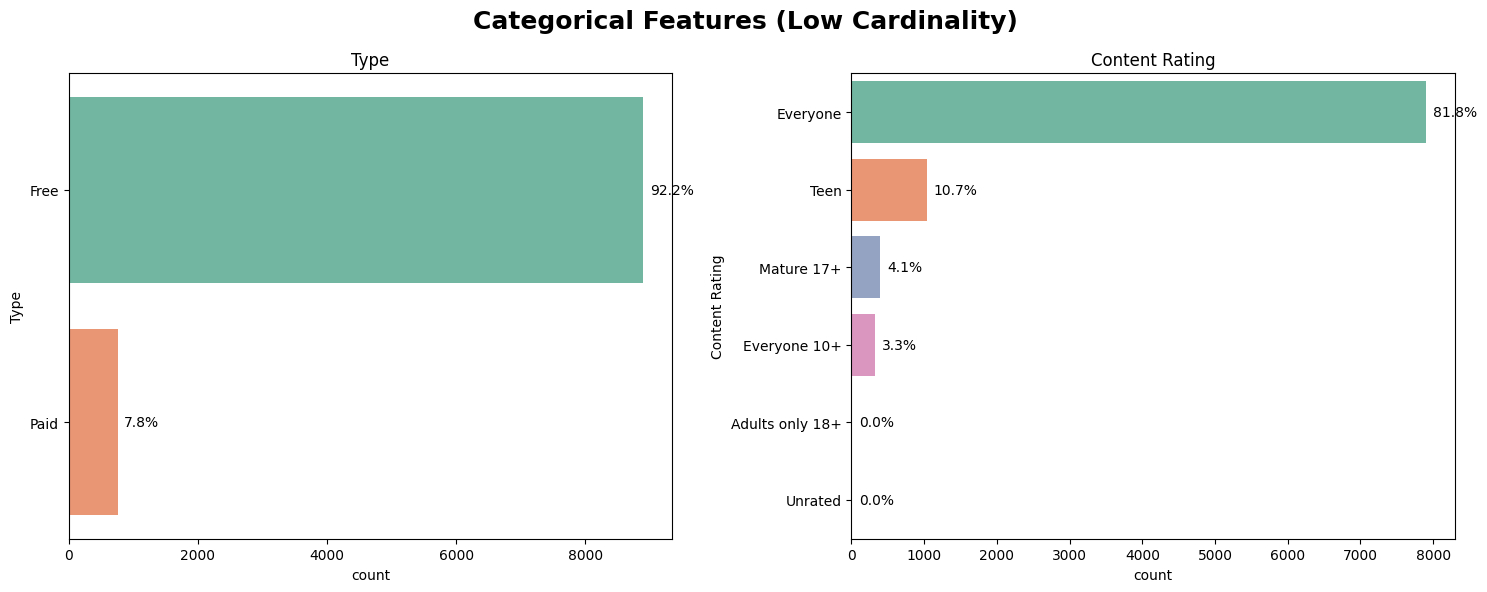

In [ ]:
#Low Clow_cardinality

import math
import seaborn as sns
import matplotlib.pyplot as plt

#Grid layout 
n_cols = 2
n_rows = math.ceil(len(low_cardinality) / n_cols) #retruns the smallest integer greater or equal to the value.

plt.figure(figsize=(15, 6 * n_rows))
plt.suptitle('Categorical Features (Low Cardinality)',
             fontsize=18, fontweight='bold')

for i, col in enumerate(low_cardinality):
    plt.subplot(n_rows, n_cols, i + 1)
    
    counts = df_cleaned[col].value_counts()
    total = counts.sum()
    percentages = (counts / total * 100).round(2)
    
    ax = sns.countplot(
        y=df_cleaned[col],
        order=counts.index,
        palette='Set2'
    )
    
    # Add percentage labels
    for j, (count, pct) in enumerate(zip(counts.values, percentages.values)):
        ax.text(count + (total * 0.01), j, f"{pct:.1f}%", va='center')
    
    plt.title(col)

plt.tight_layout()
plt.show()

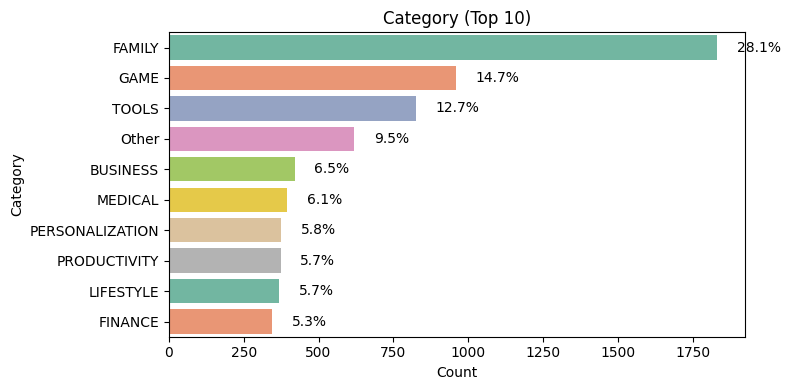

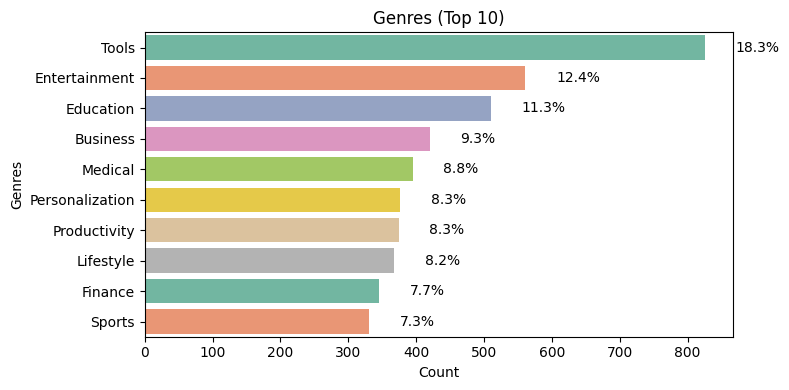

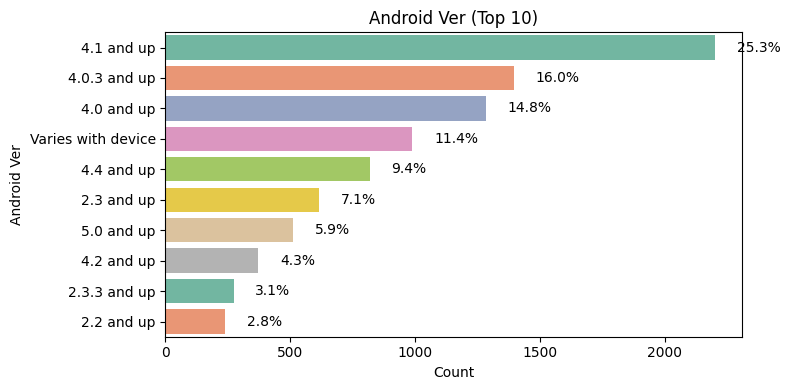

In [121]:
#High Cordinality - Top 10 only

top_n = 10

for col in high_cardinality:
    # Get top-N counts and percentages
    counts = df_cleaned[col].value_counts().nlargest(top_n)
    total = counts.sum()
    percentages = (counts / total * 100).round(2)

    plt.figure(figsize=(8, 4))
    ax = sns.countplot(
        y=df_cleaned[df_cleaned[col].isin(counts.index)][col],
        order=counts.index,
        palette='Set2'
    )

    # Add percentage labels
    for i, (count, pct) in enumerate(zip(counts.values, percentages.values)):
        ax.text(count + (total * 0.01), i, f"{pct:.1f}%", va='center')

    plt.title(f"{col} (Top {top_n})")
    plt.xlabel("Count")
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

In [123]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [ ]:
# Tasks 

#1. Category with largest number of installations 

# First we have to clean the installs as they have ','and '+' symbols

df_cleaned['Installs'] = (df_cleaned['Installs'].astype(str).str.replace(',','+').str.replace('+','').astype(int))
df_cleaned.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Last Updated Day,Last Updated Month,Last Updated Year
0,Photo Editor & Candy Camera & Grid & ScrapBook,Other,4.1,159,19000.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,7,1,2018
1,Coloring book moana,Other,3.9,967,14000.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,15,1,2018
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",Other,4.7,87510,8.7,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,1,8,2018
3,Sketch - Draw & Paint,Other,4.5,215644,25000.0,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,8,6,2018
4,Pixel Draw - Number Art Coloring Book,Other,4.3,967,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,20,6,2018


In [ ]:
# Agregating installs by category 
category_installs = df_cleaned.groupby('Category')['Installs'].sum().sort_values(ascending=False)
category_installs.head(1)

Category
GAME    13878924415
Name: Installs, dtype: int64

In [139]:
#2. Top 5 most installed apps in each popular category 

top_categories = category_installs.head(5).index # top 5 categories
top_categories

Index(['GAME', 'COMMUNICATION', 'TOOLS', 'PRODUCTIVITY', 'SOCIAL'], dtype='str', name='Category')

In [141]:
df_top = df_cleaned[df_cleaned['Category'].isin(top_categories)]
df_top.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Last Updated Day,Last Updated Month,Last Updated Year
335,Messenger – Text and Video Chat for Free,COMMUNICATION,4.0,56642847,NaN,1000000000,Free,0.0,Everyone,Communication,2018-08-01,Varies with device,Varies with device,1,8,2018
336,WhatsApp Messenger,COMMUNICATION,4.4,69119316,NaN,1000000000,Free,0.0,Everyone,Communication,2018-08-03,Varies with device,Varies with device,3,8,2018
337,Messenger for SMS,COMMUNICATION,4.3,125257,17000.0,10000000,Free,0.0,Teen,Communication,2018-06-06,1.8.9,4.1 and up,6,6,2018
338,Google Chrome: Fast & Secure,COMMUNICATION,4.3,9642995,NaN,1000000000,Free,0.0,Everyone,Communication,2018-08-01,Varies with device,Varies with device,1,8,2018
339,Messenger Lite: Free Calls & Messages,COMMUNICATION,4.4,1429035,NaN,100000000,Free,0.0,Everyone,Communication,2018-07-25,37.0.0.7.163,2.3 and up,25,7,2018


In [142]:
top_apps = (df_top.sort_values(['Category', 'Installs'], ascending=[True,False])).groupby('Category').head(5)

In [164]:
top_apps[['Category', 'App', 'Installs']]

,Category,App,Installs
335,COMMUNICATION,Messenger – Text and Video Chat for Free,1000000000
336,COMMUNICATION,WhatsApp Messenger,1000000000
338,COMMUNICATION,Google Chrome: Fast & Secure,1000000000
340,COMMUNICATION,Gmail,1000000000
341,COMMUNICATION,Hangouts,1000000000
1654,GAME,Subway Surfers,1000000000
1655,GAME,Candy Crush Saga,500000000
1661,GAME,Temple Run 2,500000000
1662,GAME,Pou,500000000
1722,GAME,My Talking Tom,500000000


In [163]:
#3. Apps with 5 star ratings with atleast more than 1000 installs

five_star_apps = df_cleaned[(df_cleaned['Rating'] == 5) & (df_cleaned['Installs'] > 1000)]
five_star_apps[['App', 'Category', 'Rating', 'Installs', 'Reviews']]

,App,Category,Rating,Installs,Reviews
7514,CL Keyboard - Myanmar Keyboard (No Ads),TOOLS,5.0,5000,24
8058,Oración CX,LIFESTYLE,5.0,5000,103
8260,"Superheroes, Marvel, DC, Comics, TV, Movies News",Other,5.0,5000,34
9511,Ek Bander Ne Kholi Dukan,FAMILY,5.0,10000,10
